In [1]:
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm


feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
# feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURE_ENGINEERING.features import *

c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\venv310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)
eplison = 1e-8

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s19['EXPECTED_USAGE_MIN'] = s19['USG_PCT_ROLLING_AVG_5'] * (s19['MIN_ROLLING_AVG_5'] + eplison)

s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s20['EXPECTED_USAGE_MIN'] = s20['USG_PCT_ROLLING_AVG_5'] * (s20['MIN_ROLLING_AVG_5'] + eplison)

s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s21['EXPECTED_USAGE_MIN'] = s21['USG_PCT_ROLLING_AVG_5'] * (s21['MIN_ROLLING_AVG_5'] + eplison)

s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s22['EXPECTED_USAGE_MIN'] = s22['USG_PCT_ROLLING_AVG_5'] * (s22['MIN_ROLLING_AVG_5'] + eplison)

s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s23['EXPECTED_USAGE_MIN'] = s23['USG_PCT_ROLLING_AVG_5'] * (s23['MIN_ROLLING_AVG_5'] + eplison)

s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s24['EXPECTED_USAGE_MIN'] = s24['USG_PCT_ROLLING_AVG_5'] * (s24['MIN_ROLLING_AVG_5'] + eplison)

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s25['EXPECTED_USAGE_MIN'] = s25['USG_PCT_ROLLING_AVG_5'] * (s25['MIN_ROLLING_AVG_5'] + eplison)

train_df = pd.concat([s19,s20,s21,s22,s23])
val_df = s24
test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
print(f"Test data shape: {test_df.shape}")
print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df

Training data shape: (123509, 983)
Training date range: 2018-10-16 to 2023-04-09
Validation data shape: (26401, 964)
Validation date range: 2023-10-24 to 2024-04-14
Test data shape: (26306, 964)
Test date range: 2024-10-22 to 2025-04-13


Unnamed: 0  Unnamed: 0.2      PLAYER_NAME  PLAYER_ID    MATCHUP  \
0               0          47.0         Alex Len     203458  ATL @ NYK   
1               1          49.0   Alex Poythress    1627816  ATL @ NYK   
2               2          48.0  DeAndre' Bembry    1627761  ATL @ NYK   
3               3          90.0     Jaylen Adams    1629121  ATL @ NYK   
4               4          87.0       Jeremy Lin     202391  ATL @ NYK   
...           ...           ...              ...        ...        ...   
25917       25917           NaN     Kobi Simmons    1628424  CHA @ CLE   
25918       25918           NaN    Mark Williams    1631109  CHA @ CLE   
25919       25919           NaN    Nick Richards    1630208  CHA @ CLE   
25920       25920           NaN   Svi Mykhailiuk    1629004  CHA @ CLE   
25921       25921           NaN     Theo Maledon    1630177  CHA @ CLE   

      TEAM_ABBREVIATION     TEAM_ID OPP_ABBREVIATION  HOME_GAME   GAME_ID  \
0                   ATL  1610612737              NYK          0  21800007   
1                   ATL  1610612737              NYK          0  21800007   
2                   ATL  1610612737              NYK          0  21800007   
3                   ATL  1610612737              NYK          0  21800007   
4                   ATL  1610612737              NYK          0  21800007   
...                 ...         ...              ...        ...       ...   
25917               CHA  1610612766              CLE          0  22201218   
25918               CHA  1610612766              CLE          0  22201218   
25919               CHA  1610612766              CLE          0  22201218   
25920               CHA  1610612766              CLE          0  22201218   
25921               CHA  1610612766              CLE          0  22201218   

        GAME_DATE WL  PTS  AST  REB  FGM  FGA  FG_PCT  FG3M  FG3A  FG3_PCT  \
0      2018-10-17  L    7    2    4    3    6   0.500     0     2    0.000   
1      2018-10-17  L    9    0    2    4    8   0.500     1     3    0.333   
2      2018-10-17  L    2    4    4    1    4   0.250     0     0      NaN   
3      2018-10-17  L    0    1    1    0    1   0.000     0     1    0.000   
4      2018-10-17  L    8    1    5    3    6   0.500     0     2    0.000   
...           ... ..  ...  ...  ...  ...  ...     ...   ...   ...      ...   
25917  2023-04-09  W    0    3    2    0    1   0.000     0     1    0.000   
25918  2023-04-09  W   22    0   10    9   10   0.900     0     0      NaN   
25919  2023-04-09  W   11    1    8    3    4   0.750     0     0      NaN   
25920  2023-04-09  W   16    6    7    6   18   0.333     2    10    0.200   
25921  2023-04-09  W   18    6    8    7   13   0.538     0     2    0.000   

       FTM  FTA  FT_PCT  OREB  DREB  STL  BLK  TOV  PLUS_MINUS  FANTASY_PTS  \
0        1    2   0.500     2     2    0    1    3         -14         14.8   
1        0    1   0.000     1     1    1    0    3         -21         11.4   
2        0    0     NaN     0     4    2    0    2         -12         16.8   
3        0    0     NaN     0     1    0    0    0           4          2.7   
4        2    2   1.000     0     5    1    0    2          -5         16.5   
...    ...  ...     ...   ...   ...  ...  ...  ...         ...          ...   
25917    0    0     NaN     1     1    0    0    0           0          6.9   
25918    4    6   0.667     1     9    1    2    2           3         41.0   
25919    5    5   1.000     2     6    1    3    3           8         31.1   
25920    2    2   1.000     4     3    2    0    3           5         36.4   
25921    4    4   1.000     1     7    1    0    3          17         36.6   

       POINT_PER_SHOT       EFG START_POSITION  COMMENT  OFF_RATING  \
0               1.017  0.500000              C      NaN        92.3   
1               1.066  0.562500            NaN      NaN        68.0   
2               0.500  0.250000            NaN      NaN        80.7   
3               0.000  

Drop 2018 from training. Add 2023-24.
• New training: 2019-2024.
• Validation: early 2025 (first half).
• Test: late 2025 or full 2025-26 once it ends.

In [18]:
newFeatures = [
    # Player context
    'STARTING', 'BLOWOUT_RISK', 'TEAM_IMPLIED_PTS_FAV', 'TEAM_IMPLIED_PTS_UND', 'HEIGHT', 'WEIGHT', 'GUARD', 'FORWARD', 'CENTER', 
    'TEAM_DAYS_REST', 'PLAYER_DAYS_REST', 'TEAM_B2B', 'IS_BACK_TO_BACK',
    
    # Rolling averages (5-game windows)
    'PTS_ROLLING_AVG_5', 'MIN_ROLLING_AVG_5', 'FGA_ROLLING_AVG_5', 'FTA_ROLLING_AVG_5', 'FG3A_ROLLING_AVG_5',
    'USG_PCT_ROLLING_AVG_5', 'TS_PCT_ROLLING_AVG_5', 'EFG_PCT_ROLLING_AVG_5',
    'PACE_ROLLING_AVG_5', 'POSS_ROLLING_AVG_5', 'TCHS_ROLLING_AVG_5', 'PASS_ROLLING_AVG_5', 'SAST_ROLLING_AVG_5',
    'FTAST_ROLLING_AVG_5', 'TOV_ROLLING_AVG_5', 'POINT_PER_SHOT_ROLLING_AVG_5', 'PLUS_MINUS_ROLLING_AVG_5',
    'NET_RATING_ROLLING_AVG_5', 'PIE_ROLLING_AVG_5', 'SPD_ROLLING_AVG_5', 'DIST_ROLLING_AVG_5',
    'percentageFieldGoalsAttempted3pt_ROLLING_AVG_5', 'percentageFieldGoalsAttempted2pt_ROLLING_AVG_5',
    'percentagePoints2pt_ROLLING_AVG_5', 'percentagePointsMidrange2pt_ROLLING_AVG_5', 'percentagePoints3pt_ROLLING_AVG_5',
    'percentagePointsFastBreak_ROLLING_AVG_5', 'percentagePointsFreeThrow_ROLLING_AVG_5', 'percentagePointsOffTurnovers_ROLLING_AVG_5',
    'percentagePointsPaint_ROLLING_AVG_5', 'percentageAssisted2pt_ROLLING_AVG_5', 'percentageUnassisted2pt_ROLLING_AVG_5',
    'percentageAssisted3pt_ROLLING_AVG_5', 'percentageUnassisted3pt_ROLLING_AVG_5',
    
    # Rolling averages (10-game windows)
    'PTS_ROLLING_AVG_10', 'MIN_ROLLING_AVG_10', 'FGA_ROLLING_AVG_10', 'FTA_ROLLING_AVG_10', 'FG3A_ROLLING_AVG_10',
    'USG_PCT_ROLLING_AVG_10', 'TS_PCT_ROLLING_AVG_10', 'EFG_PCT_ROLLING_AVG_10',
    'PACE_ROLLING_AVG_10', 'POSS_ROLLING_AVG_10', 'TCHS_ROLLING_AVG_10', 'PASS_ROLLING_AVG_10', 'SAST_ROLLING_AVG_10',
    'FTAST_ROLLING_AVG_10', 'TOV_ROLLING_AVG_10', 'POINT_PER_SHOT_ROLLING_AVG_10', 'PLUS_MINUS_ROLLING_AVG_10',
    'NET_RATING_ROLLING_AVG_10', 'PIE_ROLLING_AVG_10', 'SPD_ROLLING_AVG_10', 'DIST_ROLLING_AVG_10',
    'percentageFieldGoalsAttempted3pt_ROLLING_AVG_10', 'percentageFieldGoalsAttempted2pt_ROLLING_AVG_10',
    'percentagePoints2pt_ROLLING_AVG_10', 'percentagePointsMidrange2pt_ROLLING_AVG_10', 'percentagePoints3pt_ROLLING_AVG_10',
    'percentagePointsFastBreak_ROLLING_AVG_10', 'percentagePointsFreeThrow_ROLLING_AVG_10', 'percentagePointsOffTurnovers_ROLLING_AVG_10',
    'percentagePointsPaint_ROLLING_AVG_10', 'percentageAssisted2pt_ROLLING_AVG_10', 'percentageUnassisted2pt_ROLLING_AVG_10',
    'percentageAssisted3pt_ROLLING_AVG_10', 'percentageUnassisted3pt_ROLLING_AVG_10',
    
    # Rolling averages (15-game windows)
    'PTS_ROLLING_AVG_15', 'MIN_ROLLING_AVG_15', 'FGA_ROLLING_AVG_15', 'FTA_ROLLING_AVG_15', 'FG3A_ROLLING_AVG_15',
    'USG_PCT_ROLLING_AVG_15', 'TS_PCT_ROLLING_AVG_15', 'EFG_PCT_ROLLING_AVG_15',
    'PACE_ROLLING_AVG_15', 'POSS_ROLLING_AVG_15', 'TCHS_ROLLING_AVG_15', 'PASS_ROLLING_AVG_15', 'SAST_ROLLING_AVG_15',
    'FTAST_ROLLING_AVG_15', 'TOV_ROLLING_AVG_15', 'POINT_PER_SHOT_ROLLING_AVG_15', 'PLUS_MINUS_ROLLING_AVG_15',
    'NET_RATING_ROLLING_AVG_15', 'PIE_ROLLING_AVG_15', 'SPD_ROLLING_AVG_15', 'DIST_ROLLING_AVG_15',
    'percentageFieldGoalsAttempted3pt_ROLLING_AVG_15', 'percentageFieldGoalsAttempted2pt_ROLLING_AVG_15',
    'percentagePoints2pt_ROLLING_AVG_15', 'percentagePointsMidrange2pt_ROLLING_AVG_15', 'percentagePoints3pt_ROLLING_AVG_15',
    'percentagePointsFastBreak_ROLLING_AVG_15', 'percentagePointsFreeThrow_ROLLING_AVG_15', 'percentagePointsOffTurnovers_ROLLING_AVG_15',
    'percentagePointsPaint_ROLLING_AVG_15', 'percentageAssisted2pt_ROLLING_AVG_15', 'percentageUnassisted2pt_ROLLING_AVG_15',
    'percentageAssisted3pt_ROLLING_AVG_15', 'percentageUnassisted3pt_ROLLING_AVG_15',
    
    # Rolling averages (40-game windows)
    'PTS_ROLLING_AVG_40', 'MIN_ROLLING_AVG_40', 'FGA_ROLLING_AVG_40', 'FTA_ROLLING_AVG_40', 'FG3A_ROLLING_AVG_40',
    'USG_PCT_ROLLING_AVG_40', 'TS_PCT_ROLLING_AVG_40', 'EFG_PCT_ROLLING_AVG_40',
    'PACE_ROLLING_AVG_40', 'POSS_ROLLING_AVG_40', 'TCHS_ROLLING_AVG_40', 'PASS_ROLLING_AVG_40', 'SAST_ROLLING_AVG_40',
    'FTAST_ROLLING_AVG_40', 'TOV_ROLLING_AVG_40', 'POINT_PER_SHOT_ROLLING_AVG_40', 'PLUS_MINUS_ROLLING_AVG_40',
    'NET_RATING_ROLLING_AVG_40', 'PIE_ROLLING_AVG_40', 'SPD_ROLLING_AVG_40', 'DIST_ROLLING_AVG_40',
    'percentageFieldGoalsAttempted3pt_ROLLING_AVG_40', 'percentageFieldGoalsAttempted2pt_ROLLING_AVG_40',
    'percentagePoints2pt_ROLLING_AVG_40', 'percentagePointsMidrange2pt_ROLLING_AVG_40', 'percentagePoints3pt_ROLLING_AVG_40',
    'percentagePointsFastBreak_ROLLING_AVG_40', 'percentagePointsFreeThrow_ROLLING_AVG_40', 'percentagePointsOffTurnovers_ROLLING_AVG_40',
    'percentagePointsPaint_ROLLING_AVG_40', 'percentageAssisted2pt_ROLLING_AVG_40', 'percentageUnassisted2pt_ROLLING_AVG_40',
    'percentageAssisted3pt_ROLLING_AVG_40', 'percentageUnassisted3pt_ROLLING_AVG_40',
    
    # Matchup-specific features
    'GAMES_VS_OPP', 'MATCHUP_AVG_MIN_LAST_3_TO_DATE', 'MATCHUP_AVG_FGA_LAST_3_TO_DATE', 'MATCHUP_AVG_FG3A_LAST_3_TO_DATE',
    'MATCHUP_AVG_FTA_LAST_3_TO_DATE', 'MATCHUP_AVG_PTS_LAST_3_TO_DATE', 'MATCHUP_AVG_USG_PCT_LAST_3_TO_DATE',
    'MATCHUP_AVG_EFG_PCT_LAST_3_TO_DATE', 'MATCHUP_AVG_TS_PCT_LAST_3_TO_DATE', 'MATCHUP_AVG_POSS_LAST_3_TO_DATE',
    'MATCHUP_AVG_TCHS_LAST_3_TO_DATE', 'MATCHUP_AVG_PASS_LAST_3_TO_DATE', 'MATCHUP_AVG_SAST_LAST_3_TO_DATE',
    'MATCHUP_AVG_FTAST_LAST_3_TO_DATE', 'MATCHUP_AVG_TOV_LAST_3_TO_DATE', 'MATCHUP_AVG_POINT_PER_SHOT_LAST_3_TO_DATE',
    'MATCHUP_AVG_PLUS_MINUS_LAST_3_TO_DATE', 'MATCHUP_AVG_NET_RATING_LAST_3_TO_DATE', 'MATCHUP_AVG_PIE_LAST_3_TO_DATE',
    'MATCHUP_AVG_SPD_LAST_3_TO_DATE', 'MATCHUP_AVG_DIST_LAST_3_TO_DATE', 'MATCHUP_AVG_percentageFieldGoalsAttempted3pt_LAST_3_TO_DATE',
    'MATCHUP_AVG_percentageFieldGoalsAttempted2pt_LAST_3_TO_DATE', 'MATCHUP_AVG_percentagePoints2pt_LAST_3_TO_DATE',
    'MATCHUP_AVG_percentagePointsMidrange2pt_LAST_3_TO_DATE', 'MATCHUP_AVG_percentagePoints3pt_LAST_3_TO_DATE',
    'MATCHUP_AVG_percentagePointsFastBreak_LAST_3_TO_DATE', 'MATCHUP_AVG_percentagePointsFreeThrow_LAST_3_TO_DATE',
    'MATCHUP_AVG_percentagePointsOffTurnovers_LAST_3_TO_DATE', 'MATCHUP_AVG_percentagePointsPaint_LAST_3_TO_DATE',
    'MATCHUP_AVG_percentageAssisted2pt_LAST_3_TO_DATE', 'MATCHUP_AVG_percentageUnassisted2pt_LAST_3_TO_DATE',
    'MATCHUP_AVG_percentageAssisted3pt_LAST_3_TO_DATE', 'MATCHUP_AVG_percentageUnassisted3pt_LAST_3_TO_DATE',
    
    # Home/Away averages
    'PLAYER_HOME_AVG_PTS_TO_DATE', 'PLAYER_AWAY_AVG_PTS_TO_DATE', 'PLAYER_HOME_AVG_MIN_TO_DATE', 'PLAYER_AWAY_AVG_MIN_TO_DATE',
    'PLAYER_HOME_AVG_FGA_TO_DATE', 'PLAYER_AWAY_AVG_FGA_TO_DATE', 'PLAYER_HOME_AVG_FTA_TO_DATE', 'PLAYER_AWAY_AVG_FTA_TO_DATE',
    'PLAYER_HOME_AVG_FG3A_TO_DATE', 'PLAYER_AWAY_AVG_FG3A_TO_DATE', 'PLAYER_HOME_AVG_USG_PCT_TO_DATE', 'PLAYER_AWAY_AVG_USG_PCT_TO_DATE',
    'PLAYER_HOME_AVG_TS_PCT_TO_DATE', 'PLAYER_AWAY_AVG_TS_PCT_TO_DATE',
    'PLAYER_HOME_AVG_EFG_PCT_TO_DATE', 'PLAYER_AWAY_AVG_EFG_PCT_TO_DATE', 'PLAYER_HOME_AVG_PACE_TO_DATE', 'PLAYER_AWAY_AVG_PACE_TO_DATE',
    'PLAYER_HOME_AVG_POSS_TO_DATE', 'PLAYER_AWAY_AVG_POSS_TO_DATE', 'PLAYER_HOME_AVG_TCHS_TO_DATE', 'PLAYER_AWAY_AVG_TCHS_TO_DATE',
    'PLAYER_HOME_AVG_PASS_TO_DATE', 'PLAYER_AWAY_AVG_PASS_TO_DATE', 'PLAYER_HOME_AVG_SAST_TO_DATE', 'PLAYER_AWAY_AVG_SAST_TO_DATE',
    'PLAYER_HOME_AVG_FTAST_TO_DATE', 'PLAYER_AWAY_AVG_FTAST_TO_DATE', 'PLAYER_HOME_AVG_TOV_TO_DATE', 'PLAYER_AWAY_AVG_TOV_TO_DATE',
    'PLAYER_HOME_AVG_POINT_PER_SHOT_TO_DATE', 'PLAYER_AWAY_AVG_POINT_PER_SHOT_TO_DATE', 'PLAYER_HOME_AVG_PLUS_MINUS_TO_DATE', 'PLAYER_AWAY_AVG_PLUS_MINUS_TO_DATE',
    'PLAYER_HOME_AVG_NET_RATING_TO_DATE', 'PLAYER_AWAY_AVG_NET_RATING_TO_DATE', 'PLAYER_HOME_AVG_PIE_TO_DATE', 'PLAYER_AWAY_AVG_PIE_TO_DATE',
    'PLAYER_HOME_AVG_SPD_TO_DATE', 'PLAYER_AWAY_AVG_SPD_TO_DATE', 'PLAYER_HOME_AVG_DIST_TO_DATE', 'PLAYER_AWAY_AVG_DIST_TO_DATE',
    'PLAYER_HOME_AVG_percentageFieldGoalsAttempted3pt_TO_DATE', 'PLAYER_AWAY_AVG_percentageFieldGoalsAttempted3pt_TO_DATE',
    'PLAYER_HOME_AVG_percentageFieldGoalsAttempted2pt_TO_DATE', 'PLAYER_AWAY_AVG_percentageFieldGoalsAttempted2pt_TO_DATE',
    'PLAYER_HOME_AVG_percentagePoints2pt_TO_DATE', 'PLAYER_AWAY_AVG_percentagePoints2pt_TO_DATE',
    'PLAYER_HOME_AVG_percentagePointsMidrange2pt_TO_DATE', 'PLAYER_AWAY_AVG_percentagePointsMidrange2pt_TO_DATE',
    'PLAYER_HOME_AVG_percentagePoints3pt_TO_DATE', 'PLAYER_AWAY_AVG_percentagePoints3pt_TO_DATE',
    'PLAYER_HOME_AVG_percentagePointsFastBreak_TO_DATE', 'PLAYER_AWAY_AVG_percentagePointsFastBreak_TO_DATE',
    'PLAYER_HOME_AVG_percentagePointsFreeThrow_TO_DATE', 'PLAYER_AWAY_AVG_percentagePointsFreeThrow_TO_DATE',
    'PLAYER_HOME_AVG_percentagePointsOffTurnovers_TO_DATE', 'PLAYER_AWAY_AVG_percentagePointsOffTurnovers_TO_DATE',
    'PLAYER_HOME_AVG_percentagePointsPaint_TO_DATE', 'PLAYER_AWAY_AVG_percentagePointsPaint_TO_DATE',
    'PLAYER_HOME_AVG_percentageAssisted2pt_TO_DATE', 'PLAYER_AWAY_AVG_percentageAssisted2pt_TO_DATE',
    'PLAYER_HOME_AVG_percentageUnassisted2pt_TO_DATE', 'PLAYER_AWAY_AVG_percentageUnassisted2pt_TO_DATE',
    'PLAYER_HOME_AVG_percentageAssisted3pt_TO_DATE', 'PLAYER_AWAY_AVG_percentageAssisted3pt_TO_DATE',
    'PLAYER_HOME_AVG_percentageUnassisted3pt_TO_DATE', 'PLAYER_AWAY_AVG_percentageUnassisted3pt_TO_DATE',
    
    # Season-to-date averages
    'PTS_AVG_TO_DATE', 'MIN_AVG_TO_DATE', 'FGA_AVG_TO_DATE', 'FTA_AVG_TO_DATE', 'FG3A_AVG_TO_DATE',
    'USG_PCT_AVG_TO_DATE', 'TS_PCT_AVG_TO_DATE', 'EFG_PCT_AVG_TO_DATE',
    'PACE_AVG_TO_DATE', 'POSS_AVG_TO_DATE', 'TCHS_AVG_TO_DATE', 'PASS_AVG_TO_DATE', 'SAST_AVG_TO_DATE',
    'FTAST_AVG_TO_DATE', 'TOV_AVG_TO_DATE', 'POINT_PER_SHOT_AVG_TO_DATE', 'PLUS_MINUS_AVG_TO_DATE',
    'NET_RATING_AVG_TO_DATE', 'PIE_AVG_TO_DATE', 'SPD_AVG_TO_DATE', 'DIST_AVG_TO_DATE',
    'percentageFieldGoalsAttempted3pt_AVG_TO_DATE', 'percentageFieldGoalsAttempted2pt_AVG_TO_DATE',
    'percentagePoints2pt_AVG_TO_DATE', 'percentagePointsMidrange2pt_AVG_TO_DATE', 'percentagePoints3pt_AVG_TO_DATE',
    'percentagePointsFastBreak_AVG_TO_DATE', 'percentagePointsFreeThrow_AVG_TO_DATE', 'percentagePointsOffTurnovers_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE', 'percentageAssisted2pt_AVG_TO_DATE', 'percentageUnassisted2pt_AVG_TO_DATE',
    'percentageAssisted3pt_AVG_TO_DATE', 'percentageUnassisted3pt_AVG_TO_DATE', 'GAMES_PLAYED_TO_DATE',
    
    # Lag features
    'PTS_LAG_1', 'PTS_LAG_2', 'MIN_LAG_1', 'MIN_LAG_2', 'FGA_LAG_1', 'FGA_LAG_2', 'FTA_LAG_1', 'FTA_LAG_2',
    'FG3A_LAG_1', 'FG3A_LAG_2', 'USG_PCT_LAG_1', 'USG_PCT_LAG_2', 'TS_PCT_LAG_1', 'TS_PCT_LAG_2',
    
    # Volatility features (5-game)
    'PTS_VOLATILITY_5_TO_DATE', 'MIN_VOLATILITY_5_TO_DATE', 'FGA_VOLATILITY_5_TO_DATE', 'FTA_VOLATILITY_5_TO_DATE',
    'FG3A_VOLATILITY_5_TO_DATE', 'USG_PCT_VOLATILITY_5_TO_DATE', 'TS_PCT_VOLATILITY_5_TO_DATE',
    'EFG_PCT_VOLATILITY_5_TO_DATE', 'PACE_VOLATILITY_5_TO_DATE', 'POSS_VOLATILITY_5_TO_DATE', 'TCHS_VOLATILITY_5_TO_DATE',
    'PASS_VOLATILITY_5_TO_DATE', 'SAST_VOLATILITY_5_TO_DATE', 'FTAST_VOLATILITY_5_TO_DATE', 'TOV_VOLATILITY_5_TO_DATE',
    'percentageFieldGoalsAttempted3pt_VOLATILITY_5_TO_DATE', 'percentageFieldGoalsAttempted2pt_VOLATILITY_5_TO_DATE',
    'percentagePoints2pt_VOLATILITY_5_TO_DATE', 'percentagePointsMidrange2pt_VOLATILITY_5_TO_DATE',
    'percentagePoints3pt_VOLATILITY_5_TO_DATE', 'percentagePointsFastBreak_VOLATILITY_5_TO_DATE',
    'percentagePointsPaint_VOLATILITY_5_TO_DATE', 'percentageAssisted2pt_VOLATILITY_5_TO_DATE',
    'percentageUnassisted2pt_VOLATILITY_5_TO_DATE', 'percentageAssisted3pt_VOLATILITY_5_TO_DATE',
    'percentageUnassisted3pt_VOLATILITY_5_TO_DATE',
    
    # Volatility features (10-game)
    'PTS_VOLATILITY_10_TO_DATE', 'MIN_VOLATILITY_10_TO_DATE', 'FGA_VOLATILITY_10_TO_DATE', 'FTA_VOLATILITY_10_TO_DATE',
    'FG3A_VOLATILITY_10_TO_DATE', 'USG_PCT_VOLATILITY_10_TO_DATE', 'TS_PCT_VOLATILITY_10_TO_DATE',
    'EFG_PCT_VOLATILITY_10_TO_DATE', 'PACE_VOLATILITY_10_TO_DATE', 'POSS_VOLATILITY_10_TO_DATE', 'TCHS_VOLATILITY_10_TO_DATE',
    'PASS_VOLATILITY_10_TO_DATE', 'SAST_VOLATILITY_10_TO_DATE', 'FTAST_VOLATILITY_10_TO_DATE', 'TOV_VOLATILITY_10_TO_DATE',
    'percentageFieldGoalsAttempted3pt_VOLATILITY_10_TO_DATE', 'percentageFieldGoalsAttempted2pt_VOLATILITY_10_TO_DATE',
    'percentagePoints2pt_VOLATILITY_10_TO_DATE', 'percentagePointsMidrange2pt_VOLATILITY_10_TO_DATE',
    'percentagePoints3pt_VOLATILITY_10_TO_DATE', 'percentagePointsFastBreak_VOLATILITY_10_TO_DATE',
    'percentagePointsPaint_VOLATILITY_10_TO_DATE', 'percentageAssisted2pt_VOLATILITY_10_TO_DATE',
    'percentageUnassisted2pt_VOLATILITY_10_TO_DATE', 'percentageAssisted3pt_VOLATILITY_10_TO_DATE',
    'percentageUnassisted3pt_VOLATILITY_10_TO_DATE',
    
    # Volatility features (15-game)
    'PTS_VOLATILITY_15_TO_DATE', 'MIN_VOLATILITY_15_TO_DATE', 'FGA_VOLATILITY_15_TO_DATE', 'FTA_VOLATILITY_15_TO_DATE',
    'FG3A_VOLATILITY_15_TO_DATE', 'USG_PCT_VOLATILITY_15_TO_DATE', 'TS_PCT_VOLATILITY_15_TO_DATE',
    'EFG_PCT_VOLATILITY_15_TO_DATE', 'PACE_VOLATILITY_15_TO_DATE', 'POSS_VOLATILITY_15_TO_DATE', 'TCHS_VOLATILITY_15_TO_DATE',
    'PASS_VOLATILITY_15_TO_DATE', 'SAST_VOLATILITY_15_TO_DATE', 'FTAST_VOLATILITY_15_TO_DATE', 'TOV_VOLATILITY_15_TO_DATE',
    'percentageFieldGoalsAttempted3pt_VOLATILITY_15_TO_DATE', 'percentageFieldGoalsAttempted2pt_VOLATILITY_15_TO_DATE',
    'percentagePoints2pt_VOLATILITY_15_TO_DATE', 'percentagePointsMidrange2pt_VOLATILITY_15_TO_DATE',
    'percentagePoints3pt_VOLATILITY_15_TO_DATE', 'percentagePointsFastBreak_VOLATILITY_15_TO_DATE',
    'percentagePointsPaint_VOLATILITY_15_TO_DATE', 'percentageAssisted2pt_VOLATILITY_15_TO_DATE',
    'percentageUnassisted2pt_VOLATILITY_15_TO_DATE', 'percentageAssisted3pt_VOLATILITY_15_TO_DATE',
    'percentageUnassisted3pt_VOLATILITY_15_TO_DATE',
    
    # Expanding volatility
    'PTS_EXPANDING_VOLATILITY_TO_DATE', 'MIN_EXPANDING_VOLATILITY_TO_DATE', 'FGA_EXPANDING_VOLATILITY_TO_DATE', 'FTA_EXPANDING_VOLATILITY_TO_DATE',
    'FG3A_EXPANDING_VOLATILITY_TO_DATE', 'USG_PCT_EXPANDING_VOLATILITY_TO_DATE', 'TS_PCT_EXPANDING_VOLATILITY_TO_DATE',
    'EFG_PCT_EXPANDING_VOLATILITY_TO_DATE', 'PACE_EXPANDING_VOLATILITY_TO_DATE', 'POSS_EXPANDING_VOLATILITY_TO_DATE', 'TCHS_EXPANDING_VOLATILITY_TO_DATE',
    'PASS_EXPANDING_VOLATILITY_TO_DATE', 'SAST_EXPANDING_VOLATILITY_TO_DATE', 'FTAST_EXPANDING_VOLATILITY_TO_DATE', 'TOV_EXPANDING_VOLATILITY_TO_DATE',
    'percentageFieldGoalsAttempted3pt_EXPANDING_VOLATILITY_TO_DATE', 'percentageFieldGoalsAttempted2pt_EXPANDING_VOLATILITY_TO_DATE',
    'percentagePoints2pt_EXPANDING_VOLATILITY_TO_DATE', 'percentagePointsMidrange2pt_EXPANDING_VOLATILITY_TO_DATE',
    'percentagePoints3pt_EXPANDING_VOLATILITY_TO_DATE', 'percentagePointsFastBreak_EXPANDING_VOLATILITY_TO_DATE',
    'percentagePointsPaint_EXPANDING_VOLATILITY_TO_DATE', 'percentageAssisted2pt_EXPANDING_VOLATILITY_TO_DATE',
    'percentageUnassisted2pt_EXPANDING_VOLATILITY_TO_DATE', 'percentageAssisted3pt_EXPANDING_VOLATILITY_TO_DATE',
    'percentageUnassisted3pt_EXPANDING_VOLATILITY_TO_DATE',
    
    # Standard deviation features
    'PTS_STD_LAST_5', 'MIN_STD_LAST_5', 'FGA_STD_LAST_5', 'FTA_STD_LAST_5', 'FG3A_STD_LAST_5', 'USG_PCT_STD_LAST_5',
    'TS_PCT_STD_LAST_5', 'EFG_PCT_STD_LAST_5', 'AST_STD_LAST_5', 'REB_STD_LAST_5', 'TOV_STD_LAST_5',
    'PTS_STD_LAST_15', 'MIN_STD_LAST_15', 'FGA_STD_LAST_15', 'FTA_STD_LAST_15', 'FG3A_STD_LAST_15', 'USG_PCT_STD_LAST_15',
    'TS_PCT_STD_LAST_15', 'EFG_PCT_STD_LAST_15', 'AST_STD_LAST_15', 'REB_STD_LAST_15', 'TOV_STD_LAST_15',
    'PTS_STD_LAST_40', 'MIN_STD_LAST_40', 'FGA_STD_LAST_40', 'FTA_STD_LAST_40', 'FG3A_STD_LAST_40', 'USG_PCT_STD_LAST_40',
    'TS_PCT_STD_LAST_40', 'EFG_PCT_STD_LAST_40', 'AST_STD_LAST_40', 'REB_STD_LAST_40', 'TOV_STD_LAST_40',
    
    # High volatility flags
    'PTS_RECENT_HIGH_VOLATILITY', 'PTS_EXTREME_VOLATILITY', 'FGA_RECENT_HIGH_VOLATILITY', 'FGA_EXTREME_VOLATILITY',
    'USG_PCT_RECENT_HIGH_VOLATILITY', 'USG_PCT_EXTREME_VOLATILITY', 'TS_PCT_RECENT_HIGH_VOLATILITY', 'TS_PCT_EXTREME_VOLATILITY',
    
    # Star player features
    'PLAYER_IS_ALL_NBA', 'PLAYER_IS_TEAM_STAR', 'TEAM_STAR_OUT', 'ALL_NBA_TEAMMATE_OUT', 'NUM_ALL_NBA_ON_TEAM',
    
    # Performance without stars
    'PTS_WITHOUT_STAR', 'MIN_WITHOUT_STAR', 'USG_PCT_WITHOUT_STAR', 'FGA_WITHOUT_STAR', 'FG3A_WITHOUT_STAR',
    'FTA_WITHOUT_STAR', 'FG_PCT_WITHOUT_STAR', 'FG3_PCT_WITHOUT_STAR', 'FT_PCT_WITHOUT_STAR', 'EFG_PCT_WITHOUT_STAR',
    'TS_PCT_WITHOUT_STAR', 'AST_WITHOUT_STAR', 'POSS_WITHOUT_STAR', 'TCHS_WITHOUT_STAR', 'REB_WITHOUT_STAR',
    'TOV_WITHOUT_STAR', 'PTS_PER_36_WITHOUT_STAR', 'GAMES_WITHOUT_STAR', 'NUM_USUAL_STARTERS_PRESENT',
    
    # Team features
    'TEAM_ID_OPP', 'NUM_USUAL_STARTERS_PRESENT_OPP', 'TEAM_DEF_RATING_AVG_TO_DATE', 'TEAM_PACE_AVG_TO_DATE',
    'TEAM_OFF_RATING_AVG_TO_DATE', 'TEAM_PTS_AVG_TO_DATE', 'TEAM_FGA_AVG_TO_DATE', 'TEAM_REB_AVG_TO_DATE',
    'TEAM_AST_AVG_TO_DATE', 'TEAM_TOV_AVG_TO_DATE', 'OPP_DEF_RATING_AVG_TO_DATE', 'OPP_PACE_AVG_TO_DATE',
    'OPP_PTS_AVG_TO_DATE', 'OPP_FGA_AVG_TO_DATE', 'OPP_REB_AVG_TO_DATE', 'OPP_AST_AVG_TO_DATE',
    'OPP_TOV_AVG_TO_DATE', 'OPP_BLK_AVG_TO_DATE', 'OPP_STL_AVG_TO_DATE',
    
    # Team rolling averages (5-game)
    'TEAM_DEF_RATING_ROLLING_AVG_5', 'TEAM_PACE_ROLLING_AVG_5', 'TEAM_OFF_RATING_ROLLING_AVG_5', 'TEAM_PTS_ROLLING_AVG_5',
    'TEAM_FGA_ROLLING_AVG_5', 'TEAM_REB_ROLLING_AVG_5', 'TEAM_AST_ROLLING_AVG_5', 'TEAM_TOV_ROLLING_AVG_5',
    'TEAM_BLK_ROLLING_AVG_5', 'TEAM_STL_ROLLING_AVG_5',
    
    # Team rolling averages (10-game)
    'TEAM_DEF_RATING_ROLLING_AVG_10', 'TEAM_PACE_ROLLING_AVG_10', 'TEAM_OFF_RATING_ROLLING_AVG_10', 'TEAM_PTS_ROLLING_AVG_10',
    'TEAM_FGA_ROLLING_AVG_10', 'TEAM_REB_ROLLING_AVG_10', 'TEAM_AST_ROLLING_AVG_10', 'TEAM_TOV_ROLLING_AVG_10',
    'TEAM_BLK_ROLLING_AVG_10', 'TEAM_STL_ROLLING_AVG_10',
    
    # Team rolling averages (15-game)
    'TEAM_DEF_RATING_ROLLING_AVG_15', 'TEAM_PACE_ROLLING_AVG_15', 'TEAM_OFF_RATING_ROLLING_AVG_15', 'TEAM_PTS_ROLLING_AVG_15',
    'TEAM_FGA_ROLLING_AVG_15', 'TEAM_REB_ROLLING_AVG_15', 'TEAM_AST_ROLLING_AVG_15', 'TEAM_TOV_ROLLING_AVG_15',
    'TEAM_BLK_ROLLING_AVG_15', 'TEAM_STL_ROLLING_AVG_15',
    
    # Opponent team rolling averages (5-game)
    'OPP_TEAM_DEF_RATING_ROLLING_AVG_5', 'OPP_TEAM_PACE_ROLLING_AVG_5', 'OPP_TEAM_OFF_RATING_ROLLING_AVG_5', 'OPP_TEAM_PTS_ROLLING_AVG_5',
    'OPP_TEAM_FGA_ROLLING_AVG_5', 'OPP_TEAM_REB_ROLLING_AVG_5', 'OPP_TEAM_AST_ROLLING_AVG_5', 'OPP_TEAM_TOV_ROLLING_AVG_5',
    'OPP_TEAM_BLK_ROLLING_AVG_5', 'OPP_TEAM_STL_ROLLING_AVG_5',
    
    # Opponent team rolling averages (10-game)
    'OPP_TEAM_DEF_RATING_ROLLING_AVG_10', 'OPP_TEAM_PACE_ROLLING_AVG_10', 'OPP_TEAM_OFF_RATING_ROLLING_AVG_10', 'OPP_TEAM_PTS_ROLLING_AVG_10',
    'OPP_TEAM_FGA_ROLLING_AVG_10', 'OPP_TEAM_REB_ROLLING_AVG_10', 'OPP_TEAM_AST_ROLLING_AVG_10', 'OPP_TEAM_TOV_ROLLING_AVG_10',
    'OPP_TEAM_BLK_ROLLING_AVG_10', 'OPP_TEAM_STL_ROLLING_AVG_10',
    
    # Opponent team rolling averages (15-game)
    'OPP_TEAM_DEF_RATING_ROLLING_AVG_15', 'OPP_TEAM_PACE_ROLLING_AVG_15', 'OPP_TEAM_OFF_RATING_ROLLING_AVG_15', 'OPP_TEAM_PTS_ROLLING_AVG_15',
    'OPP_TEAM_FGA_ROLLING_AVG_15', 'OPP_TEAM_REB_ROLLING_AVG_15', 'OPP_TEAM_AST_ROLLING_AVG_15', 'OPP_TEAM_TOV_ROLLING_AVG_15',
    'OPP_TEAM_BLK_ROLLING_AVG_15', 'OPP_TEAM_STL_ROLLING_AVG_15',
    
    # Interaction features
    'EXPECTED_PACE', 'TEAM_OFF_MINUS_OPP_DEF', 'TEAM_PACE_MINUS_OPP_PACE', 'TEAM_PTS_MINUS_OPP_PTS',
    'USG_X_PACE', 'USG_X_TEAM_OFF', 'MIN_X_PACE', 'PLAYER_3PT_X_OPP_3PT_DEF',
    'PLAYER_PAINT_X_OPP_PAINT_DEF', 'PLAYER_MID_X_OPP_MID_DEF', 'PLAYER_3PT_X_OPP_3PT_DEF_RECENT',
    'PLAYER_PAINT_X_OPP_PAINT_DEF_RECENT', 'PLAYER_MID_X_OPP_MID_DEF_RECENT', 'ROLLING_PTS5_X_PACE',
    'ROLLING_PTS5_X_TEAM_OFF', 'ROLLING_MIN5_X_TEAM_PTS', 'REST_X_PACE', 'B2B_X_PACE', 'STARTER_X_PACE',
    'TEAM_STAR_OUT_X_USG', 'TEAM_STAR_OUT_X_MIN', 'TEAM_STAR_OUT_X_PTS', 'HOME_X_MIN', 'HOME_X_PTS',
    'HOME_X_PACE', 'EFG_X_FGA', 'TS_X_USG', 'EFG_X_MIN', 'PTS_PER_MIN', 'PTS_PER_36',
    'PTS_PER_MIN_ROLLING_AVG_5', 'PTS_PER_MIN_ROLLING_AVG_15', 'PTS_PER_MIN_ROLLING_AVG_40',
    'PTS_PER_MIN_X_PACE', 'EXPECTED_USAGE_MIN'
]

In [19]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor

def select_features_xgb_importance(X, y, top_n=150):
    xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb.fit(X, y)
    
    # Get feature importance
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': xgb.feature_importances_
    }).sort_values('importance', ascending=False)
    
    top_features = importance_df.head(top_n)['feature'].tolist()
    return X[top_features], top_features

# Select top 300 features from your newFeatures array
selected_features, top_features = select_features_xgb_importance(
    train_df[newFeatures], 
    train_df['PTS'], 
    top_n=100
)

# Apply the same feature selection to your other datasets
test_df_selected = test_df[top_features]
val_df_selected = val_df[top_features]

# Get the selected training data
train_df_selected = train_df[top_features]

print(f"Selected {len(top_features)} features from your newFeatures array")
print(f"Top 10 most important features:")
for i, feature in enumerate(top_features[:10]):
    print(f"{i+1}. {feature}")

Selected 100 features from your newFeatures array
Top 10 most important features:
1. PTS_ROLLING_AVG_40
2. EXPECTED_USAGE_MIN
3. PTS_ROLLING_AVG_15
4. FGA_ROLLING_AVG_10
5. FG3A_ROLLING_AVG_10
6. PLAYER_PAINT_X_OPP_PAINT_DEF
7. PTS_WITHOUT_STAR
8. PTS_ROLLING_AVG_10
9. FGA_LAG_1
10. PTS_AVG_TO_DATE


# XGBOOST MODEL

In [20]:
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint


def build_recent_weights(df, player_col, recent_n=30, recent_weight=3.0):
    w = np.ones(len(df), dtype=float)
    idx = df.groupby(player_col, sort=False).tail(recent_n).index
    w[idx] = recent_weight
    return w

def clean_feature_dtypes(X, cat_cols):
    Xc = X.copy()
    for c in Xc.columns:
        if c in cat_cols:
            continue
        if Xc[c].dtype == "bool":
            Xc[c] = Xc[c].astype(int)
        elif not np.issubdtype(Xc[c].dtype, np.number):
            Xc[c] = pd.to_numeric(Xc[c], errors="coerce")
    return Xc

def xgb_params(base=None, use_gpu=False):
    p = dict(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method='hist',
        booster='gbtree',
        random_state=42,
        n_jobs=-1,
        
        n_estimators=5000,
        learning_rate=0.01412139968434072, 
        max_depth=9,
        min_child_weight=3, #help balance overfitting vs underfitting   
        
        subsample=0.73338144662399,
        colsample_bytree=0.6460723242676091,
        
        gamma=0.7327236865873834,
        reg_alpha=3.4421579214044646,
        reg_lambda=50.16154429033941,
        
        early_stopping_rounds=75, 
        verbosity=1
    )
    if base:
        p.update(base)
    if use_gpu:
        p["tree_method"] = "gpu_hist"
        p["gpu_id"] = 0
        p["n_jobs"] = 1
    return p

def tune_xgb_hyperparams(X_train, y_train, X_val, y_val, sample_weight=None, use_gpu=False, n_iter=50):
    base_params = xgb_params(use_gpu=use_gpu)
    base_params.pop("early_stopping_rounds", None)

    xgb = XGBRegressor(**base_params)

    param_dist = {
        "max_depth": randint(3, 10),
        "min_child_weight": randint(1, 10),
        "subsample": uniform(0.5, 0.5),       # 0.5–1.0
        "colsample_bytree": uniform(0.5, 0.5),
        "gamma": uniform(0, 2),
        "reg_alpha": uniform(0, 9),
        "reg_lambda": uniform(1, 50),
        "learning_rate": uniform(0.005, 0.02)
    }

    search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring="r2",
        n_jobs=-1,
        cv=[(range(len(y_train)), range(len(y_val)))],  # train/val split manually defined
        verbose=1,
        random_state=42
    )

    X = pd.concat([X_train, X_val], ignore_index=True)
    y = np.concatenate([y_train, y_val])
    
    if sample_weight is not None:
        val_weights = np.ones(len(y_val))
        combined_sample_weight = np.concatenate([sample_weight, val_weights])
    else:
        combined_sample_weight = None
    
    search.fit(X, y, sample_weight=combined_sample_weight)

    print("Best params:", search.best_params_)
    print("Best R²:", search.best_score_)

    return search.best_params_

def fit_train_val(
    train_df, val_df,
    features, target_col, date_col, player_col,
    recent_n=30, recent_weight=3.0,
    params=None, use_gpu=False, tune_hyperparams=False, tune_iters=50):

    train_df = train_df.sort_values(date_col).reset_index(drop=True)
    val_df = val_df.sort_values(date_col).reset_index(drop=True)

    X_tr = train_df[features]
    y_tr = train_df[target_col].to_numpy()
    X_va = val_df[features]
    y_va = val_df[target_col].to_numpy()

    X_tr = clean_feature_dtypes(X_tr, set())
    X_va = clean_feature_dtypes(X_va, set())
    w_tr = build_recent_weights(train_df, player_col, recent_n, recent_weight)
    
    if tune_hyperparams:
        best_params = tune_xgb_hyperparams(
        X_tr, y_tr, X_va, y_va, sample_weight=w_tr,
        use_gpu=use_gpu, n_iter=tune_iters
    )
        p = xgb_params(best_params, use_gpu=use_gpu)
    else:
        p = xgb_params(params, use_gpu=use_gpu)
    
    # clean types (no categorical handling needed)
    X_tr = clean_feature_dtypes(X_tr, set())
    X_va = clean_feature_dtypes(X_va, set())

    # sample weights
    w_tr = build_recent_weights(train_df, player_col, recent_n, recent_weight)

    # Get parameters
    p = xgb_params(params, use_gpu=use_gpu)
    
    # Create model
    model = XGBRegressor(**p)
    
    # Fit with early stopping - removed early_stopping_rounds from here
    model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )

    best_iter = model.best_iteration if hasattr(model, 'best_iteration') else p["n_estimators"]

    # retrain final model on train+val
    p_final = xgb_params(params, use_gpu=use_gpu)
    p_final["n_estimators"] = int(best_iter)
    p_final.pop("early_stopping_rounds", None)
    
    full_df = pd.concat([train_df, val_df], ignore_index=True)
    X_full = clean_feature_dtypes(full_df[features], set())
    y_full = full_df[target_col].to_numpy()
    
    w_full = np.concatenate([
        build_recent_weights(train_df, player_col, recent_n, recent_weight),
        np.ones(len(val_df))
    ])

    final_model = XGBRegressor(**p_final)
    final_model.fit(X_full, y_full, sample_weight=w_full, verbose=False)

    # validation metrics
    val_preds = model.predict(X_va)
    diff = val_preds - y_va
    val_rmse = float(np.sqrt(np.mean(diff**2)))
    val_mae = float(np.mean(np.abs(diff)))
    val_r2 = float(r2_score(y_va, val_preds))

    return final_model, dict(RMSE=val_rmse, MAE=val_mae, R2=val_r2, best_iteration=int(best_iter)), []

def evaluate_test(model, test_df, features, target_col, cat_cols):
    X_te = clean_feature_dtypes(test_df[features], set())
    y_te = test_df[target_col].to_numpy()
    
    preds = model.predict(X_te)
    diff = preds - y_te

    rmse = float(np.sqrt(np.mean(diff**2)))
    mae = float(np.mean(np.abs(diff)))
    r2 = float(r2_score(y_te, preds))

    residuals_df = pd.DataFrame({
        "actual": y_te,
        "predicted": preds,
        "residual": diff
    })
    
    # Join back some useful context for grouping
    context_cols = ["PLAYER_NAME", "MATCHUP", "TEAM_PTS", "OPP_PTS", "STARTING","PLAYER_IS_TEAM_STAR", "TEAM_STAR_OUT",'HOME_GAME', 'MIN']
    available_cols = [c for c in context_cols if c in test_df.columns]
    residuals_df = residuals_df.join(test_df[available_cols])
    
    return dict(RMSE=rmse, MAE=mae, R2=r2), residuals_df

In [21]:
xgbModel, val_metrics, used_cats = fit_train_val(
    train_df, val_df,
    features=top_features,
    target_col="PTS",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False,
    tune_hyperparams=False,
    tune_iters=100
)

print("Validation metrics:", val_metrics)

test_metrics, residuals_df = evaluate_test(xgbModel, test_df, top_features, "PTS", used_cats)
print("Test metrics:", test_metrics)


Validation metrics: {'RMSE': 5.276240290080072, 'MAE': 3.9713338251151185, 'R2': 0.6550651788711548, 'best_iteration': 747}
Test metrics: {'RMSE': 5.343296578303138, 'MAE': 4.0258665766905555, 'R2': 0.6311525106430054}


In [23]:
feature_importance = pd.DataFrame({
    'feature': top_features,
    'importance': xgbModel.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 vs Bottom 25 Features - Side by Side")
print("=" * 100)

# Get top 25 and bottom 25
top25 = feature_importance.head(25).reset_index(drop=True)
bottom25 = feature_importance.tail(25).reset_index(drop=True)

# Reset index for bottom 25 to start from 0
bottom25 = bottom25.reset_index(drop=True)

# Create side-by-side comparison
comparison = pd.concat([
    top25.rename(columns={'feature': 'TOP_FEATURES', 'importance': 'TOP_IMPORTANCE'}),
    bottom25.rename(columns={'feature': 'BOTTOM_FEATURES', 'importance': 'BOTTOM_IMPORTANCE'})
], axis=1)

print(comparison.to_string(index=False))

Top 25 vs Bottom 25 Features - Side by Side
                        TOP_FEATURES  TOP_IMPORTANCE                                        BOTTOM_FEATURES  BOTTOM_IMPORTANCE
                  PTS_ROLLING_AVG_15        0.193630                   USG_PCT_EXPANDING_VOLATILITY_TO_DATE           0.001690
                  PTS_ROLLING_AVG_40        0.161838                                    PASS_ROLLING_AVG_10           0.001689
                  EXPECTED_USAGE_MIN        0.110392                                       TCHS_AVG_TO_DATE           0.001670
                     PTS_AVG_TO_DATE        0.081190                percentagePointsFreeThrow_ROLLING_AVG_5           0.001643
                  PTS_ROLLING_AVG_10        0.068039                     MATCHUP_AVG_USG_PCT_LAST_3_TO_DATE           0.001643
                            STARTING        0.044165            percentagePointsPaint_VOLATILITY_15_TO_DATE           0.001632
        PLAYER_PAINT_X_OPP_PAINT_DEF        0.025227               

In [24]:
# Residuals analysis
res = residuals_df.sort_values(by='residual', ascending=False, inplace=True)
top25errors = residuals_df.head(30).reset_index(drop=True)
top25errors

,actual,predicted,residual,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,PLAYER_IS_TEAM_STAR,TEAM_STAR_OUT,HOME_GAME,MIN
0,5,28.831928,23.831928,Tyrese Maxey,PHI vs. GSW,126,119.0,1,0,1,1,39.82
1,9,32.432934,23.432934,Anthony Edwards,MIN vs. BKN,117,91.0,1,1,0,1,30.52
2,5,26.202515,21.202515,Brandon Ingram,NOP vs. OKC,109,119.0,1,0,1,1,18.90
3,0,20.693504,20.693504,Anfernee Simons,POR vs. LAC,89,118.0,1,0,0,1,29.87
4,3,22.944218,19.944218,Desmond Bane,MEM @ OKC,104,125.0,1,0,1,0,31.80
5,10,29.900425,19.900425,Anthony Davis,LAL @ SAC,103,99.0,1,0,1,0,37.32
6,7,26.709227,19.709227,Jalen Green,HOU vs. GSW,121,127.0,1,1,0,1,33.70
7,2,21.098749,19.098749,Coby White,CHI @ PHI,122,102.0,1,0,1,0,18.78
8,6,24.950741,18.950741,Jalen Green,HOU @ MIA,102,98.0,1,1,0,0,32.22
9,4,22.748186,18.748186,Bennedict Mathurin,IND @ DEN,125,120.0,0,0,1,0,21.05


In [28]:
joblib.dump(xgbModel, 'Models/xgbModel.pkl')
joblib.dump(top_features, 'Models/top_features.pkl')

['Models/top_features.pkl']

C:\Users\alexg\AppData\Local\Temp\ipykernel_19960\1302807732.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
C:\Users\alexg\AppData\Local\Temp\ipykernel_19960\1302807732.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])


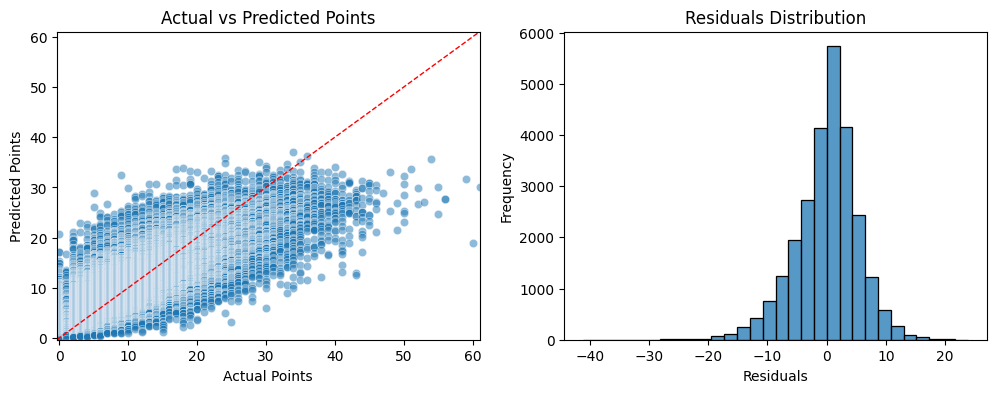

In [25]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
minVal = min(residuals_df['actual'].min(), residuals_df['predicted'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['predicted'].max())
axes[0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0].set_xlim(minVal, maxVal)
axes[0].set_ylim(minVal, maxVal)
axes[0].set_title('Actual vs Predicted Points')
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')

sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.show()

- Currently my model isnt able to predict games were players score above 30+ points

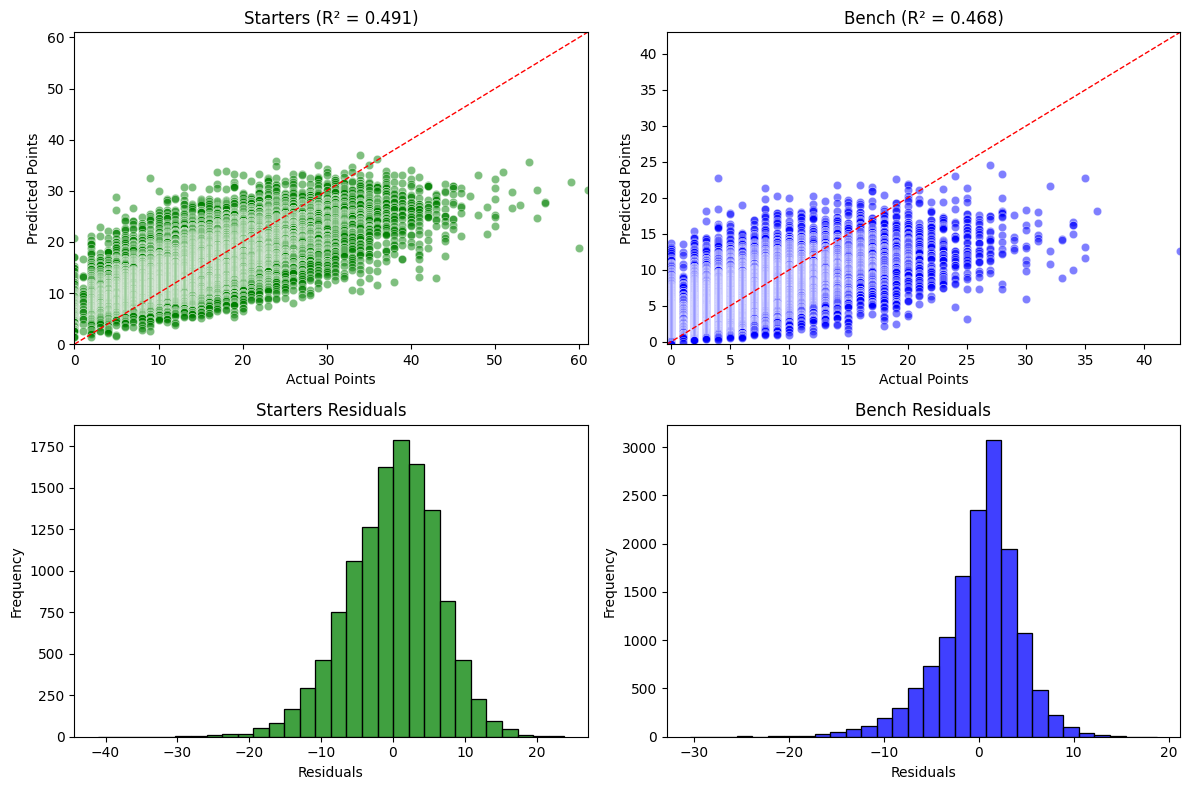

In [26]:
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]
starters_r2 = r2_score(starters['actual'], starters['predicted'])
bench_r2 = r2_score(bench['actual'], bench['predicted'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

sns.scatterplot(x='actual', y='predicted', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['predicted'].min())
maxVal = max(starters['actual'].max(), starters['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Starters (R² = {starters_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['predicted'].min())
maxVal = max(bench['actual'].max(), bench['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Bench (R² = {bench_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starters['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(bench['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()


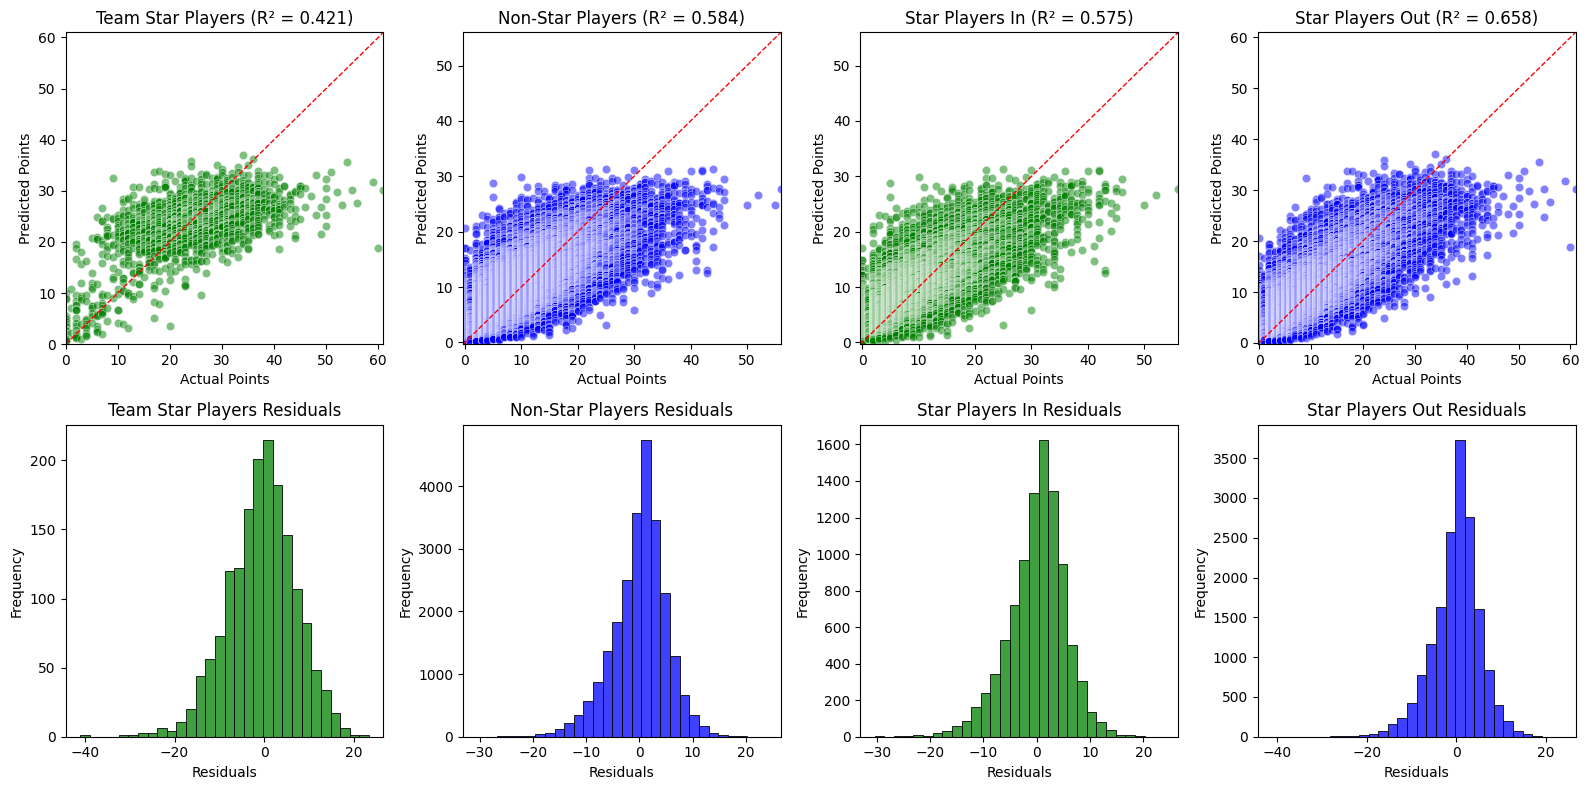

In [27]:
starPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 1]
nonStarPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 0]
star_r2 = r2_score(starPlayers['actual'], starPlayers['predicted'])
nonStar_r2 = r2_score(nonStarPlayers['actual'], nonStarPlayers['predicted'])

starsIn = residuals_df[residuals_df['TEAM_STAR_OUT'] == 1]
starsOut = residuals_df[residuals_df['TEAM_STAR_OUT'] == 0]
starsIn_r2 = r2_score(starsIn['actual'], starsIn['predicted'])
starsOut_r2 = r2_score(starsOut['actual'], starsOut['predicted'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  

# Team Star Players
sns.scatterplot(x='actual', y='predicted', data=starPlayers, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starPlayers['actual'].min(), starPlayers['predicted'].min())
maxVal = max(starPlayers['actual'].max(), starPlayers['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Team Star Players (R² = {star_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Non-Star Players
sns.scatterplot(x='actual', y='predicted', data=nonStarPlayers, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(nonStarPlayers['actual'].min(), nonStarPlayers['predicted'].min())
maxVal = max(nonStarPlayers['actual'].max(), nonStarPlayers['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Non-Star Players (R² = {nonStar_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# Star Players In
sns.scatterplot(x='actual', y='predicted', data=starsIn, color='green', alpha=0.5, ax=axes[0,2])
minVal = min(starsIn['actual'].min(), starsIn['predicted'].min())
maxVal = max(starsIn['actual'].max(), starsIn['predicted'].max())
axes[0,2].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,2].set_xlim(minVal, maxVal)
axes[0,2].set_ylim(minVal, maxVal)
axes[0,2].set_title(f'Star Players In (R² = {starsIn_r2:.3f})')
axes[0,2].set_xlabel('Actual Points')
axes[0,2].set_ylabel('Predicted Points')

# Star Players Out
sns.scatterplot(x='actual', y='predicted', data=starsOut, color='blue', alpha=0.5, ax=axes[0,3])
minVal = min(starsOut['actual'].min(), starsOut['predicted'].min())
maxVal = max(starsOut['actual'].max(), starsOut['predicted'].max())
axes[0,3].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,3].set_xlim(minVal, maxVal)
axes[0,3].set_ylim(minVal, maxVal)
axes[0,3].set_title(f'Star Players Out (R² = {starsOut_r2:.3f})')
axes[0,3].set_xlabel('Actual Points')
axes[0,3].set_ylabel('Predicted Points')

# Residual histograms
sns.histplot(starPlayers['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Team Star Players Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(nonStarPlayers['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Non-Star Players Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

sns.histplot(starsIn['residual'], bins=30, color='green', ax=axes[1,2])
axes[1,2].set_title('Star Players In Residuals')
axes[1,2].set_xlabel('Residuals')
axes[1,2].set_ylabel('Frequency')

sns.histplot(starsOut['residual'], bins=30, color='blue', ax=axes[1,3])
axes[1,3].set_title('Star Players Out Residuals')
axes[1,3].set_xlabel('Residuals')
axes[1,3].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

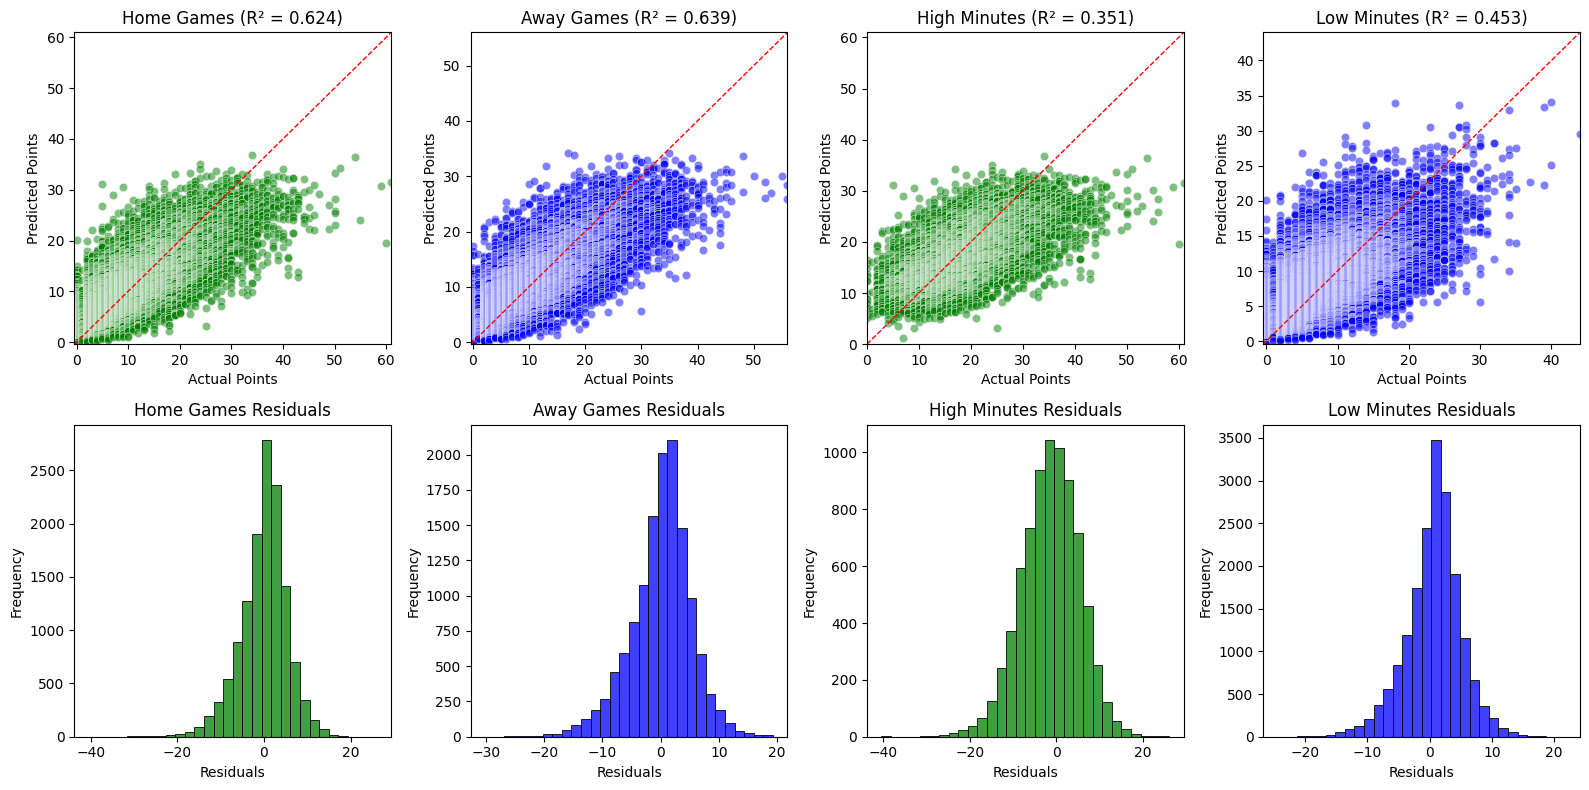

In [13]:
homeGames = residuals_df[residuals_df['HOME_GAME'] == 1]
awayGames = residuals_df[residuals_df['HOME_GAME'] == 0]
homeGames_r2 = r2_score(homeGames['actual'], homeGames['predicted'])
awayGames_r2 = r2_score(awayGames['actual'], awayGames['predicted'])

highMins = residuals_df[residuals_df['MIN'] > 30]
lowMins = residuals_df[residuals_df['MIN'] <= 30]
highMins_r2 = r2_score(highMins['actual'], highMins['predicted'])
lowMins_r2 = r2_score(lowMins['actual'], lowMins['predicted'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  

# Home Games
sns.scatterplot(x='actual', y='predicted', data=homeGames, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(homeGames['actual'].min(), homeGames['predicted'].min())
maxVal = max(homeGames['actual'].max(), homeGames['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Home Games (R² = {homeGames_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Away Games
sns.scatterplot(x='actual', y='predicted', data=awayGames, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(awayGames['actual'].min(), awayGames['predicted'].min())
maxVal = max(awayGames['actual'].max(), awayGames['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Away Games (R² = {awayGames_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# High Minutes
sns.scatterplot(x='actual', y='predicted', data=highMins, color='green', alpha=0.5, ax=axes[0,2])
minVal = min(highMins['actual'].min(), highMins['predicted'].min())
maxVal = max(highMins['actual'].max(), highMins['predicted'].max())
axes[0,2].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,2].set_xlim(minVal, maxVal)
axes[0,2].set_ylim(minVal, maxVal)
axes[0,2].set_title(f'High Minutes (R² = {highMins_r2:.3f})')
axes[0,2].set_xlabel('Actual Points')
axes[0,2].set_ylabel('Predicted Points')

# Low Minutes
sns.scatterplot(x='actual', y='predicted', data=lowMins, color='blue', alpha=0.5, ax=axes[0,3])
minVal = min(lowMins['actual'].min(), lowMins['predicted'].min())
maxVal = max(lowMins['actual'].max(), lowMins['predicted'].max())
axes[0,3].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,3].set_xlim(minVal, maxVal)
axes[0,3].set_ylim(minVal, maxVal)
axes[0,3].set_title(f'Low Minutes (R² = {lowMins_r2:.3f})')
axes[0,3].set_xlabel('Actual Points')
axes[0,3].set_ylabel('Predicted Points')

# Residual histograms
sns.histplot(homeGames['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Home Games Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(awayGames['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Away Games Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

sns.histplot(highMins['residual'], bins=30, color='green', ax=axes[1,2])
axes[1,2].set_title('High Minutes Residuals')
axes[1,2].set_xlabel('Residuals')
axes[1,2].set_ylabel('Frequency')

sns.histplot(lowMins['residual'], bins=30, color='blue', ax=axes[1,3])
axes[1,3].set_title('Low Minutes Residuals')
axes[1,3].set_xlabel('Residuals')
axes[1,3].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()